# Football Player Market Value Prediction & Scouting Dashboard
## Notebook 3 — Modelling


This notebook builds four position-specific market value models (FWD, MID, DEF, GK), each trained on the full feature set with Ridge, Random Forest, XGBoost, and LightGBM under 5-fold stratified cross-validation, tuned via RandomizedSearchCV. The best-performing algorithm per position is retained and explained with SHAP, which is also used to directly quantify the average contribution of league affiliation and nationality/confederation to predicted market value — the core bias-detection mechanism for the dissertation's research question. No train/test split is used; the 2024-25 dataset is evaluated entirely through cross-validation. A parallel feature ablation experiment reuses the same CV folds on a reduced 22-column feature set to measure how much predictive power the advanced FBref metrics (xG, passing, possession, GCA) actually contribute over basic stats.

This notebook produces, per position: a trained best model, SHAP values, and diagnostic plots (predicted vs. actual, residuals). Combined outputs include `results_summary.csv` (model performance across all algorithms and positions), `bias_summary.csv` (average SHAP contribution by league and confederation), and `df_predictions.csv` (every player's predicted value, value ratio/gap, and undervalued-player flag), all saved to `data/processed/` for use in the Streamlit dashboard.

This notebook uses each player's latest Transfermarkt valuation on or before **2025-06-30** (contemporaneous with the 2024-25 season) as the modelling target — the adopted valuation cutoff for this project, replacing an earlier version that used 2025-12-31. Outputs are written to `data/processed/`, the live directory used by the dashboard. The earlier December-cutoff version is preserved separately in `data/processed_december2025_reference/` for comparison.

## Step 1 — Setup

Loads the four position-specific datasets (`df_fwd`, `df_mid`, `df_def`, `df_gk`) and the ablation dataset from `data/processed/`, and checks their shapes and null rates against what notebook 2 produced, to confirm nothing drifted before modelling begins. Also creates the `models/` and `shap_values/` output folders used later in the notebook.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

PROCESSED = Path("../data/processed/")
MODELS_DIR = PROCESSED / "models"
SHAP_DIR = PROCESSED / "shap_values"
for d in [MODELS_DIR, SHAP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

dfs = {
    'FWD': pd.read_csv(PROCESSED / "df_fwd.csv"),
    'MID': pd.read_csv(PROCESSED / "df_mid.csv"),
    'DEF': pd.read_csv(PROCESSED / "df_def.csv"),
    'GK':  pd.read_csv(PROCESSED / "df_gk.csv"),
}
df_ablation = pd.read_csv(PROCESSED / "df_ablation.csv")

expected_trimmed = {'FWD': (487, 167), 'MID': (637, 167), 'DEF': (778, 167), 'GK': (159, 199)}

print("=== shape check ===")
for pos, df in dfs.items():
    exp = expected_trimmed[pos]
    match = df.shape == exp
    print(f"{pos}: got {df.shape}, expected {exp} -> {'OK' if match else 'MISMATCH'}")

print(f"\nablation: got {df_ablation.shape}, expected (2061, 22) -> "
      f"{'OK' if df_ablation.shape == (2061, 22) else 'MISMATCH'}")

print("\n=== null check: contract_months_remaining ===")
for pos, df in dfs.items():
    if 'contract_months_remaining' in df.columns:
        null_pct = df['contract_months_remaining'].isna().mean()
        print(f"{pos}: {null_pct:.1%} null")

print("\n=== log_market_value describe (all positions) ===")
for pos, df in dfs.items():
    print(f"{pos}: mean={df['log_market_value'].mean():.2f}, "
          f"std={df['log_market_value'].std():.2f}, "
          f"min={df['log_market_value'].min():.2f}, max={df['log_market_value'].max():.2f}")

=== shape check ===
FWD: got (487, 167), expected (487, 167) -> OK
MID: got (637, 167), expected (637, 167) -> OK
DEF: got (778, 167), expected (778, 167) -> OK
GK: got (159, 199), expected (159, 199) -> OK

ablation: got (2061, 22), expected (2061, 22) -> OK

=== null check: contract_months_remaining ===
FWD: 2.5% null
MID: 3.0% null
DEF: 4.5% null
GK: 5.7% null

=== log_market_value describe (all positions) ===
FWD: mean=15.93, std=1.34, min=10.82, max=19.11
MID: mean=15.85, std=1.23, min=11.51, max=19.01
DEF: mean=15.58, std=1.22, min=12.61, max=18.20
GK: mean=15.24, std=1.30, min=12.61, max=17.50


## Step 2 — Shared Preprocessing Helpers

Defines the feature preparation function used by every position model: 
drops identity/leakage columns, handles the `contract_months_remaining` 
nulls (median impute + `missing_contract` flag), and one-hot encodes 
`career_stage` and `foot`. Also defines the stratified CV bins and the 
back-transformation utilities (log → euros) used for evaluation 
throughout the notebook.

In [2]:
import re

def prepare_features(df):
    """Prepare X, y, and a lookup table from a position-specific dataframe."""
    df = df.copy()

    lookup_cols = [c for c in ['Player', 'Squad', 'Comp', 'Nation'] if c in df.columns]
    df_lookup = df[lookup_cols].copy()

    y = df['log_market_value'].copy()

    df['missing_contract'] = df['contract_months_remaining'].isna().astype(int)
    df['contract_months_remaining'] = df['contract_months_remaining'].fillna(
        df['contract_months_remaining'].median()
    )

    df = pd.get_dummies(df, columns=['career_stage'], prefix='career_stage')
    if 'foot' in df.columns:
        df = pd.get_dummies(df, columns=['foot'], prefix='foot')

    drop_cols = [c for c in [
        'Player', 'Squad', 'Nation', 'Pos', 'Comp', 'tm_player_id', 'player_id',
        'market_value_in_eur', 'date', 'nation_code', 'confederation',
        'date_of_birth', 'contract_expiration_date', 'Born', 'position_group',
        'log_market_value', 'match_method', 'country_of_citizenship', 'Age'
    ] if c in df.columns]
    X = df.drop(columns=drop_cols)

    # rate/ratio columns (contain % or / in original name): NaN means zero-denominator
    rate_like_cols = [c for c in X.columns if '%' in str(c) or '/' in str(c)]
    X[rate_like_cols] = X[rate_like_cols].fillna(0)

    # catch-all: fill any remaining NaN with 0, and print exactly what got filled
    remaining_nan_cols = X.columns[X.isna().any()].tolist()
    if remaining_nan_cols:
        print(f"WARNING: filling remaining NaN with 0 in: {remaining_nan_cols}")
        X[remaining_nan_cols] = X[remaining_nan_cols].fillna(0)

    non_numeric = X.select_dtypes(exclude=['number', 'bool']).columns.tolist()
    if non_numeric:
        print(f"WARNING: non-numeric columns still present: {non_numeric}")

    X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(c)) for c in X.columns]

    if X.columns.duplicated().any():
        dupes = X.columns[X.columns.duplicated()].tolist()
        print(f"WARNING: sanitizing created duplicate column names: {dupes}")
        cols = X.columns.tolist()
        seen = {}
        new_cols = []
        for c in cols:
            if cols.count(c) > 1:
                seen[c] = seen.get(c, 0) + 1
                new_cols.append(f"{c}_{seen[c]}")
            else:
                new_cols.append(c)
        X.columns = new_cols

    return X, y, df_lookup


def make_strat_bins(y, n_bins=5):
    return pd.qcut(y, q=n_bins, labels=False, duplicates='drop')


def back_transform(y_log):
    return np.expm1(y_log)


def eval_metrics(y_true_log, y_pred_log):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae = mean_absolute_error(y_true_log, y_pred_log)
    r2 = r2_score(y_true_log, y_pred_log)

    y_true_eur = back_transform(y_true_log)
    y_pred_eur = back_transform(y_pred_log)
    mape = np.mean(np.abs((y_true_eur - y_pred_eur) / y_true_eur)) * 100

    return {'RMSE_log': rmse, 'MAE_log': mae, 'R2': r2, 'MAPE_eur_pct': mape}

## Step 3 — Primary Position Models

Trains four algorithms (Ridge, Random Forest, XGBoost, LightGBM) per 
position group, using 5-fold stratified cross-validation (stratified on 
the quantile-binned target from Step 2) with `RandomizedSearchCV` for 
hyperparameter tuning. For each position, the best-performing algorithm 
by cross-validated RMSE is retained, refit on the full position dataset, 
and saved to `models/best_model_{position}.pkl`. All four algorithms' 
CV metrics (RMSE, MAE, R², MAPE) are logged to a running results table 
that will be saved as `results_summary.csv` at the end of the notebook. 
GK results are computed the same way as the other three positions but 
should be read as exploratory given the smaller sample (159 players).

In [3]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb

param_grids = {
    # keyed 'ridge__alpha' because Ridge is wrapped in a scaling Pipeline below —
    # unscaled Ridge unfairly penalises it against tree ensembles that don't need scaling
    'Ridge': {
        'ridge__alpha': [0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]
    },
    'RandomForest': {
        'n_estimators': [200, 300, 500],
        'max_depth': [5, 8, 10, 15, None],
        'min_samples_leaf': [1, 2, 4, 8],
        'max_features': ['sqrt', 0.5, 0.8]
    },
    'XGBoost': {
        'n_estimators': [200, 300, 500],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    },
    'LightGBM': {
        'n_estimators': [200, 300, 500],
        'num_leaves': [15, 31, 63],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    }
}

models_base = {
    'Ridge': Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(random_state=42))]),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
}

results_summary = []

def train_position(position, df, n_iter=25, n_splits=5):
    """Run all 4 algorithms for one position, return best model + its name."""
    print(f"\n{'='*50}\n{position}\n{'='*50}")

    X, y, lookup = prepare_features(df)
    bins = make_strat_bins(y, n_bins=5)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_folds = list(skf.split(X, bins))  # materialized once — reusable & picklable

    best_score = np.inf
    best_model = None
    best_name = None

    for name, base_model in models_base.items():
        search = RandomizedSearchCV(
            base_model,
            param_distributions=param_grids[name],
            n_iter=n_iter,
            cv=cv_folds,
            scoring='neg_root_mean_squared_error',
            random_state=42,
            n_jobs=-1
        )
        search.fit(X, y)

        y_pred_cv = cross_val_predict(search.best_estimator_, X, y, cv=cv_folds)
        metrics = eval_metrics(y, y_pred_cv)

        print(f"{name}: RMSE={metrics['RMSE_log']:.4f}  MAE={metrics['MAE_log']:.4f}  "
              f"R2={metrics['R2']:.4f}  MAPE={metrics['MAPE_eur_pct']:.1f}%  "
              f"| best params: {search.best_params_}")

        results_summary.append({
            'position': position, 'algorithm': name, **metrics,
            'best_params': search.best_params_
        })

        if metrics['RMSE_log'] < best_score:
            best_score = metrics['RMSE_log']
            best_model = search.best_estimator_
            best_name = name

    best_model.fit(X, y)
    joblib.dump(best_model, MODELS_DIR / f"best_model_{position.lower()}.pkl")
    print(f"\n>>> Best for {position}: {best_name} (RMSE={best_score:.4f}) — saved.")

    return best_name, best_model, X, y, lookup


best_name_fwd, best_model_fwd, X_fwd, y_fwd, lookup_fwd = train_position('FWD', dfs['FWD'])


FWD


Ridge: RMSE=0.6781  MAE=0.4879  R2=0.7416  MAPE=91.0%  | best params: {'ridge__alpha': 100.0}


RandomForest: RMSE=0.7179  MAE=0.5291  R2=0.7104  MAPE=96.0%  | best params: {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15}


XGBoost: RMSE=0.6550  MAE=0.4841  R2=0.7589  MAPE=78.2%  | best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


LightGBM: RMSE=0.6659  MAE=0.4826  R2=0.7508  MAPE=82.9%  | best params: {'subsample': 0.6, 'num_leaves': 15, 'n_estimators': 500, 'learning_rate': 0.01, 'colsample_bytree': 0.8}



>>> Best for FWD: XGBoost (RMSE=0.6550) — saved.


In [4]:
best_name_mid, best_model_mid, X_mid, y_mid, lookup_mid = train_position('MID', dfs['MID'])


MID
Ridge: RMSE=0.6284  MAE=0.4657  R2=0.7371  MAPE=66.4%  | best params: {'ridge__alpha': 100.0}


/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

...

/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

RandomForest: RMSE=0.6758  MAE=0.5218  R2=0.6960  MAPE=70.0%  | best params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 10}


XGBoost: RMSE=0.6246  MAE=0.4662  R2=0.7403  MAPE=62.1%  | best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


LightGBM: RMSE=0.6141  MAE=0.4584  R2=0.7490  MAPE=60.9%  | best params: {'subsample': 0.8, 'num_leaves': 15, 'n_estimators': 500, 'learning_rate': 0.03, 'colsample_bytree': 0.6}



>>> Best for MID: LightGBM (RMSE=0.6141) — saved.


In [5]:
best_name_def, best_model_def, X_def, y_def, lookup_def = train_position('DEF', dfs['DEF'])


DEF
Ridge: RMSE=0.5882  MAE=0.4573  R2=0.7665  MAPE=53.8%  | best params: {'ridge__alpha': 100.0}


/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

...

/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

RandomForest: RMSE=0.6255  MAE=0.4898  R2=0.7359  MAPE=57.9%  | best params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 10}


XGBoost: RMSE=0.5653  MAE=0.4404  R2=0.7843  MAPE=51.4%  | best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


LightGBM: RMSE=0.5713  MAE=0.4422  R2=0.7797  MAPE=52.4%  | best params: {'subsample': 0.8, 'num_leaves': 15, 'n_estimators': 500, 'learning_rate': 0.03, 'colsample_bytree': 0.6}



>>> Best for DEF: XGBoost (RMSE=0.5653) — saved.


In [6]:
best_name_gk, best_model_gk, X_gk, y_gk, lookup_gk = train_position('GK', dfs['GK'])


GK
Ridge: RMSE=0.7535  MAE=0.6124  R2=0.6615  MAPE=74.7%  | best params: {'ridge__alpha': 100.0}


RandomForest: RMSE=0.8011  MAE=0.6739  R2=0.6174  MAPE=82.2%  | best params: {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15}


XGBoost: RMSE=0.7403  MAE=0.6151  R2=0.6733  MAPE=75.7%  | best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


LightGBM: RMSE=0.7240  MAE=0.6028  R2=0.6875  MAPE=74.1%  | best params: {'subsample': 0.8, 'num_leaves': 63, 'n_estimators': 500, 'learning_rate': 0.01, 'colsample_bytree': 0.6}



>>> Best for GK: LightGBM (RMSE=0.7240) — saved.


## Checkpoint — Save Results Summary

Saves the cross-validated performance metrics collected across all four 
positions and four algorithms (16 rows total) to `results_summary.csv`, 
before moving on to the feature ablation experiment in Section 4.

In [7]:
results_df = pd.DataFrame(results_summary)
results_df.to_csv(PROCESSED / "results_summary.csv", index=False)

print(f"Saved {len(results_df)} rows to results_summary.csv")
print(results_df[['position', 'algorithm', 'RMSE_log', 'MAE_log', 'R2', 'MAPE_eur_pct']])

Saved 16 rows to results_summary.csv
   position     algorithm  RMSE_log   MAE_log        R2  MAPE_eur_pct
0       FWD         Ridge  0.678120  0.487859  0.741600     91.020649
1       FWD  RandomForest  0.717863  0.529101  0.710424     95.960291
2       FWD       XGBoost  0.655046  0.484112  0.758885     78.188875
3       FWD      LightGBM  0.665903  0.482560  0.750827     82.888985
4       MID         Ridge  0.628443  0.465688  0.737121     66.442205
5       MID  RandomForest  0.675773  0.521819  0.696033     70.006871
6       MID       XGBoost  0.624587  0.466211  0.740337     62.053464
7       MID      LightGBM  0.614066  0.458352  0.749011     60.890435
8       DEF         Ridge  0.588190  0.457315  0.766498     53.770602
9       DEF  RandomForest  0.625529  0.489839  0.735910     57.945020
10      DEF       XGBoost  0.565270  0.440369  0.784341     51.351975
11      DEF      LightGBM  0.571294  0.442225  0.779720     52.358062
12       GK         Ridge  0.753521  0.612358  0.6615

## Section 4 — Feature Ablation Experiment
Quantifies how much predictive power the advanced FBref metrics (xG, detailed passing, possession, GCA) actually contribute, by retraining on a reduced 22-column feature set restricted to metrics also present in the 2025-26 season data — run once on the pooled dataset (all positions together) rather than per position, since the ablation set doesn't include the fine-grained positional stats that motivated splitting by position in the first place. 

Results are compared against Section 3's full-feature models to answer: how much accuracy do we lose by dropping to the basic stat categories available in both seasons? This is a standalone finding for the dissertation methodology chapter.

In [8]:
nation_to_confederation = {
    # UEFA
    'al ALB': 'UEFA', 'am ARM': 'UEFA', 'at AUT': 'UEFA', 'ba BIH': 'UEFA',
    'be BEL': 'UEFA', 'ch SUI': 'UEFA', 'cy CYP': 'UEFA', 'cz CZE': 'UEFA',
    'de GER': 'UEFA', 'dk DEN': 'UEFA', 'ee EST': 'UEFA', 'eng ENG': 'UEFA',
    'es ESP': 'UEFA', 'fi FIN': 'UEFA', 'fr FRA': 'UEFA', 'ge GEO': 'UEFA',
    'gr GRE': 'UEFA', 'hr CRO': 'UEFA', 'hu HUN': 'UEFA', 'ie IRL': 'UEFA',
    'il ISR': 'UEFA', 'is ISL': 'UEFA', 'it ITA': 'UEFA', 'lt LTU': 'UEFA',
    'lu LUX': 'UEFA', 'me MNE': 'UEFA', 'mk MKD': 'UEFA', 'mt MLT': 'UEFA',
    'nir NIR': 'UEFA', 'nl NED': 'UEFA', 'no NOR': 'UEFA', 'pl POL': 'UEFA',
    'pt POR': 'UEFA', 'ro ROU': 'UEFA', 'rs SRB': 'UEFA', 'ru RUS': 'UEFA',
    'sct SCO': 'UEFA', 'se SWE': 'UEFA', 'si SVN': 'UEFA', 'sk SVK': 'UEFA',
    'tr TUR': 'UEFA', 'ua UKR': 'UEFA', 'wls WAL': 'UEFA', 'xk KVX': 'UEFA',

    # CAF
    'ao ANG': 'CAF', 'bf BFA': 'CAF', 'bi BDI': 'CAF', 'bj BEN': 'CAF',
    'cd COD': 'CAF', 'cf CTA': 'CAF', 'cg CGO': 'CAF', 'ci CIV': 'CAF',
    'cm CMR': 'CAF', 'cv CPV': 'CAF', 'dz ALG': 'CAF', 'eg EGY': 'CAF',
    'ga GAB': 'CAF', 'gh GHA': 'CAF', 'gm GAM': 'CAF', 'gn GUI': 'CAF',
    'gq EQG': 'CAF', 'gw GNB': 'CAF', 'ke KEN': 'CAF', 'ly LBY': 'CAF',
    'ma MAR': 'CAF', 'mg MAD': 'CAF', 'ml MLI': 'CAF', 'mz MOZ': 'CAF',
    'ng NGA': 'CAF', 'sl SLE': 'CAF', 'sn SEN': 'CAF', 'tg TOG': 'CAF',
    'tn TUN': 'CAF', 'zm ZAM': 'CAF', 'zw ZIM': 'CAF',

    # CONMEBOL
    'ar ARG': 'CONMEBOL', 'br BRA': 'CONMEBOL', 'cl CHI': 'CONMEBOL',
    'co COL': 'CONMEBOL', 'ec ECU': 'CONMEBOL', 'gf GUF': 'CONMEBOL',
    'pe PER': 'CONMEBOL', 'py PAR': 'CONMEBOL', 'uy URU': 'CONMEBOL',
    've VEN': 'CONMEBOL',

    # CONCACAF
    'ca CAN': 'CONCACAF', 'do DOM': 'CONCACAF', 'gp GLP': 'CONCACAF',
    'ht HAI': 'CONCACAF', 'jm JAM': 'CONCACAF', 'mx MEX': 'CONCACAF',
    'sr SUR': 'CONCACAF', 'us USA': 'CONCACAF',

    # AFC
    'au AUS': 'AFC', 'id IDN': 'AFC', 'ir IRN': 'AFC', 'jp JPN': 'AFC',
    'kr KOR': 'AFC', 'my MAS': 'AFC', 'ph PHI': 'AFC', 'uz UZB': 'AFC',

    # OFC
    'nz NZL': 'OFC',
}

# verify complete coverage before applying
missing = set(df_ablation['Nation'].unique()) - set(nation_to_confederation.keys())
print(f"Unmapped codes: {missing}")

Unmapped codes: set()


In [9]:
def prepare_ablation_features(df):
    """Prepare X, y for the ablation dataset. Reconstructs league dummies
    from raw Comp and confederation dummies from raw Nation (via lookup),
    so the reduced-feature comparison isolates the effect of dropping
    advanced stats specifically — not also dropping league/nationality
    signal, which would confound the experiment."""
    df = df.copy()

    y = df['log_market_value'].copy()

    if 'Comp' in df.columns:
        df = pd.get_dummies(df, columns=['Comp'], prefix='league')

    if 'Nation' in df.columns:
        df['confederation'] = df['Nation'].map(nation_to_confederation)
        unmapped = df['confederation'].isna().sum()
        if unmapped > 0:
            print(f"WARNING: {unmapped} players with unmapped Nation — check lookup table")
        df = pd.get_dummies(df, columns=['confederation'], prefix='confed')

    drop_cols = [c for c in [
        'Player', 'Squad', 'Nation', 'Pos', 'tm_player_id', 'player_id',
        'market_value_in_eur', 'Born', 'position_group', 'log_market_value', 'Age'
    ] if c in df.columns]
    X = df.drop(columns=drop_cols)

    rate_like_cols = [c for c in X.columns if '%' in str(c) or '/' in str(c)]
    X[rate_like_cols] = X[rate_like_cols].fillna(0)

    remaining_nan_cols = X.columns[X.isna().any()].tolist()
    if remaining_nan_cols:
        print(f"WARNING: filling remaining NaN with 0 in: {remaining_nan_cols}")
        X[remaining_nan_cols] = X[remaining_nan_cols].fillna(0)

    non_numeric = X.select_dtypes(exclude=['number', 'bool']).columns.tolist()
    if non_numeric:
        print(f"WARNING: non-numeric columns still present: {non_numeric}")

    X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(c)) for c in X.columns]

    if X.columns.duplicated().any():
        dupes = X.columns[X.columns.duplicated()].tolist()
        print(f"WARNING: sanitizing created duplicate column names: {dupes}")
        cols = X.columns.tolist()
        seen = {}
        new_cols = []
        for c in cols:
            if cols.count(c) > 1:
                seen[c] = seen.get(c, 0) + 1
                new_cols.append(f"{c}_{seen[c]}")
            else:
                new_cols.append(c)
        X.columns = new_cols

    return X, y


X_abl, y_abl = prepare_ablation_features(df_ablation)
print(f"Ablation X shape: {X_abl.shape}")
print(f"Columns: {list(X_abl.columns)}")

Ablation X shape: (2061, 22)
Columns: ['90s', 'CrdR', 'CrdY', 'Gls', 'Ast', 'MP_playing_time', 'Min_playing_time', 'PK', 'Starts_playing_time', 'PKatt_shooting', 'age_precise', 'league_de_Bundesliga', 'league_eng_Premier_League', 'league_es_La_Liga', 'league_fr_Ligue_1', 'league_it_Serie_A', 'confed_AFC', 'confed_CAF', 'confed_CONCACAF', 'confed_CONMEBOL', 'confed_OFC', 'confed_UEFA']


## Section 4 (cont.) — Ablation Training
Trains Ridge, Random Forest, XGBoost, and LightGBM on the 22-column ablation set (basic stats + reconstructed league/confederation dummies), using the same 5-fold stratified CV as Section 3.

In [10]:
ablation_results = []

def train_ablation(X, y, n_iter=25, n_splits=5):
    """Run all 4 algorithms on the ablation feature set."""
    print(f"\n{'='*50}\nABLATION (pooled, all positions)\n{'='*50}")

    bins = make_strat_bins(y, n_bins=5)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_folds = list(skf.split(X, bins))

    best_score = np.inf
    best_model = None
    best_name = None

    for name, base_model in models_base.items():
        search = RandomizedSearchCV(
            base_model,
            param_distributions=param_grids[name],
            n_iter=n_iter,
            cv=cv_folds,
            scoring='neg_root_mean_squared_error',
            random_state=42,
            n_jobs=-1
        )
        search.fit(X, y)

        y_pred_cv = cross_val_predict(search.best_estimator_, X, y, cv=cv_folds)
        metrics = eval_metrics(y, y_pred_cv)

        print(f"{name}: RMSE={metrics['RMSE_log']:.4f}  MAE={metrics['MAE_log']:.4f}  "
              f"R2={metrics['R2']:.4f}  MAPE={metrics['MAPE_eur_pct']:.1f}%  "
              f"| best params: {search.best_params_}")

        ablation_results.append({
            'position': 'ALL_ABLATION', 'algorithm': name, **metrics,
            'best_params': search.best_params_
        })

        if metrics['RMSE_log'] < best_score:
            best_score = metrics['RMSE_log']
            best_model = search.best_estimator_
            best_name = name

    best_model.fit(X, y)
    joblib.dump(best_model, MODELS_DIR / "best_model_ablation.pkl")
    print(f"\n>>> Best for ablation: {best_name} (RMSE={best_score:.4f}) — saved.")

    return best_name, best_model


best_name_abl, best_model_abl = train_ablation(X_abl, y_abl)


ABLATION (pooled, all positions)
Ridge: RMSE=0.8756  MAE=0.6831  R2=0.5249  MAPE=105.0%  | best params: {'ridge__alpha': 20.0}


RandomForest: RMSE=0.8661  MAE=0.6781  R2=0.5352  MAPE=94.8%  | best params: {'n_estimators': 500, 'min_samples_leaf': 4, 'max_features': 0.8, 'max_depth': 8}


XGBoost: RMSE=0.8509  MAE=0.6660  R2=0.5514  MAPE=96.0%  | best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


LightGBM: RMSE=0.8524  MAE=0.6653  R2=0.5498  MAPE=93.6%  | best params: {'subsample': 0.6, 'num_leaves': 15, 'n_estimators': 500, 'learning_rate': 0.01, 'colsample_bytree': 0.8}



>>> Best for ablation: XGBoost (RMSE=0.8509) — saved.


In [11]:
ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv(PROCESSED / "ablation_results.csv", index=False)
print(f"Saved {len(ablation_df)} rows to ablation_results.csv")
print(ablation_df[['algorithm', 'RMSE_log', 'MAE_log', 'R2', 'MAPE_eur_pct']])

Saved 4 rows to ablation_results.csv
      algorithm  RMSE_log   MAE_log        R2  MAPE_eur_pct
0         Ridge  0.875620  0.683106  0.524932    105.011865
1  RandomForest  0.866072  0.678092  0.535236     94.788712
2       XGBoost  0.850921  0.665985  0.551355     96.015290
3      LightGBM  0.852439  0.665281  0.549753     93.584899


## Section 5 — SHAP Explainability & League/Nationality Bias Quantification

Runs SHAP (SHapley Additive exPlanations) on each position's best model 
to produce two things:

1. **Global feature importance per position** — the standard SHAP summary, 
   showing which stats drive predicted value most, for the results chapter.
2. **League and confederation bias quantification** — the core RQ2 
   deliverable. For every player, SHAP decomposes their predicted value 
   into per-feature contributions. Aggregating the SHAP values specifically 
   attributed to `league_*` and `confed_*` features (averaged within each 
   league/confederation) gives the average contribution of league 
   affiliation and nationality to predicted market value, holding all 
   performance stats constant — this directly answers whether players are 
   systematically over/undervalued by league or nationality independent 
   of their stats.

Uses TreeExplainer for XGBoost/LightGBM/RandomForest (fast, exact for 
tree ensembles) and LinearExplainer for Ridge (in case Ridge is ever the 
best model for a position). Per-player SHAP values are saved for each 
position for use in the Streamlit dashboard's Player Lookup and League 
& Nationality Bias Explorer pages.

/Users/ashish/Desktop/UoBD MSc Project/Football-PlayerValuation/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



SHAP — FWD (XGBRegressor)
SHAP values shape: (487, 154)
Saved to shap_values_fwd.pkl


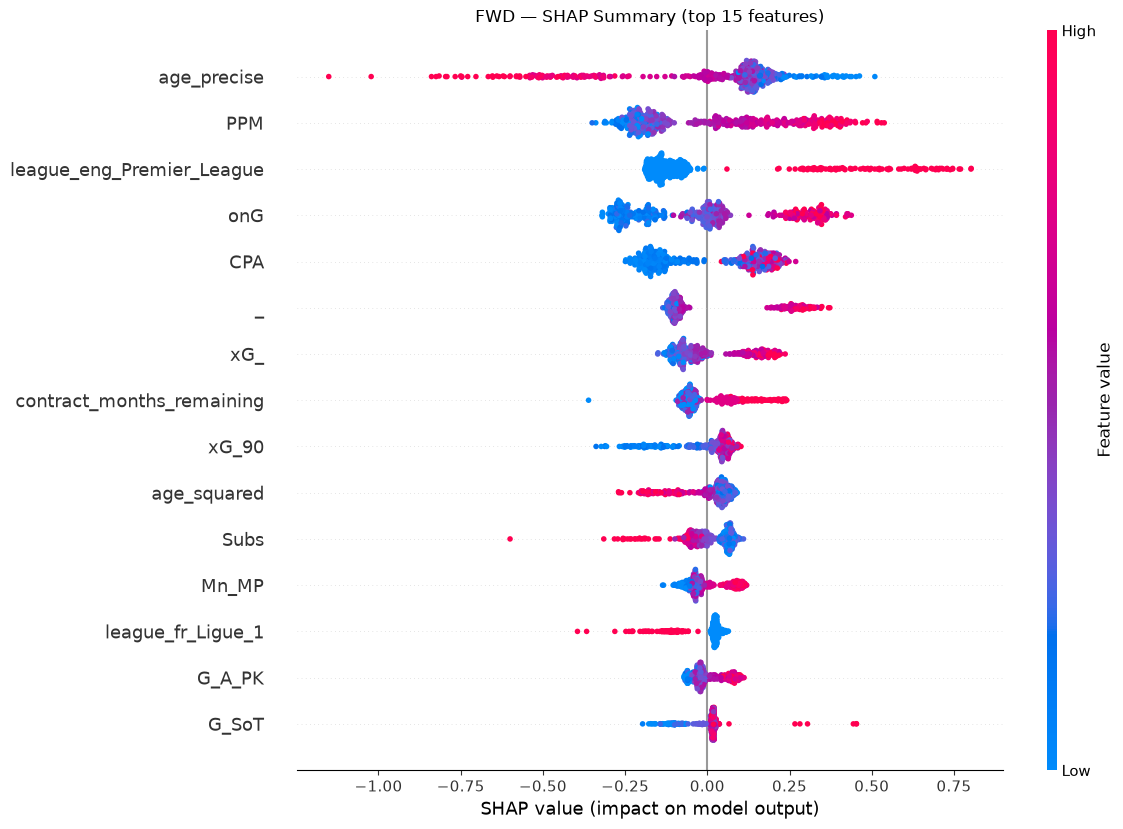

Plot saved to shap_summary_fwd.png

SHAP — MID (LGBMRegressor)
SHAP values shape: (637, 154)
Saved to shap_values_mid.pkl


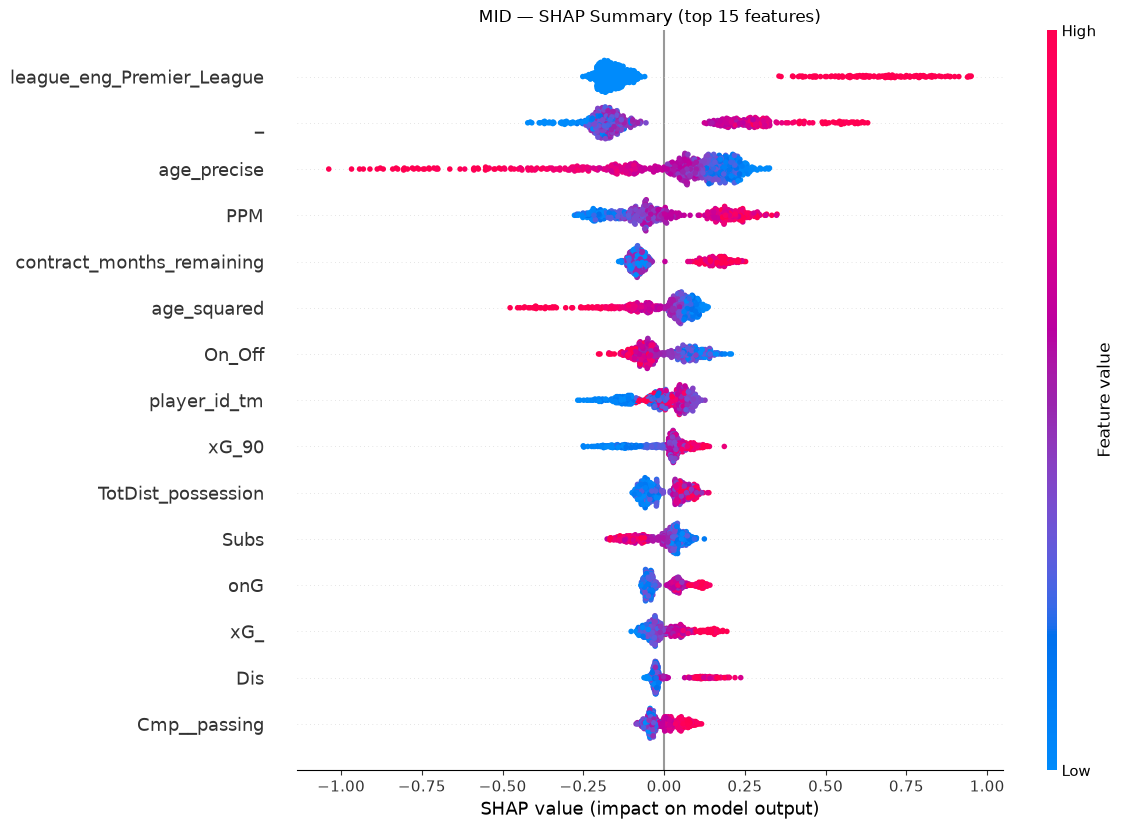

Plot saved to shap_summary_mid.png

SHAP — DEF (XGBRegressor)
SHAP values shape: (778, 154)
Saved to shap_values_def.pkl


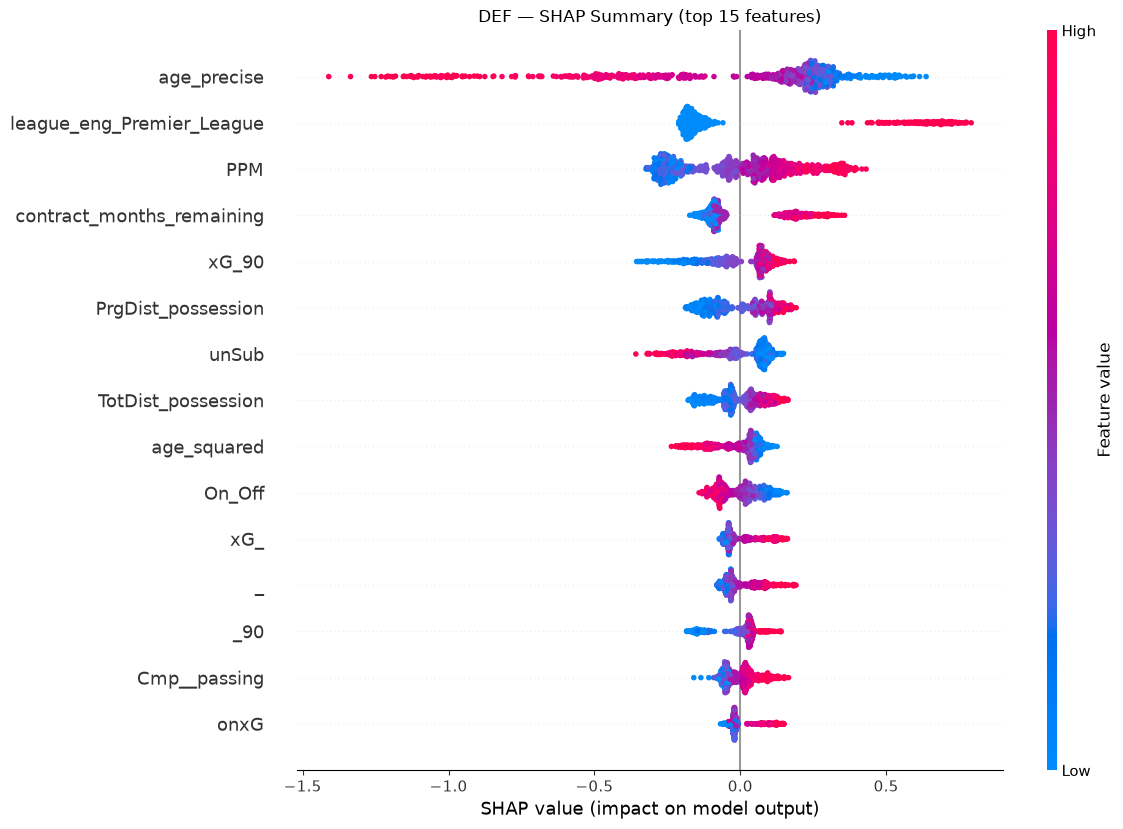

Plot saved to shap_summary_def.png

SHAP — GK (LGBMRegressor)
SHAP values shape: (159, 186)
Saved to shap_values_gk.pkl


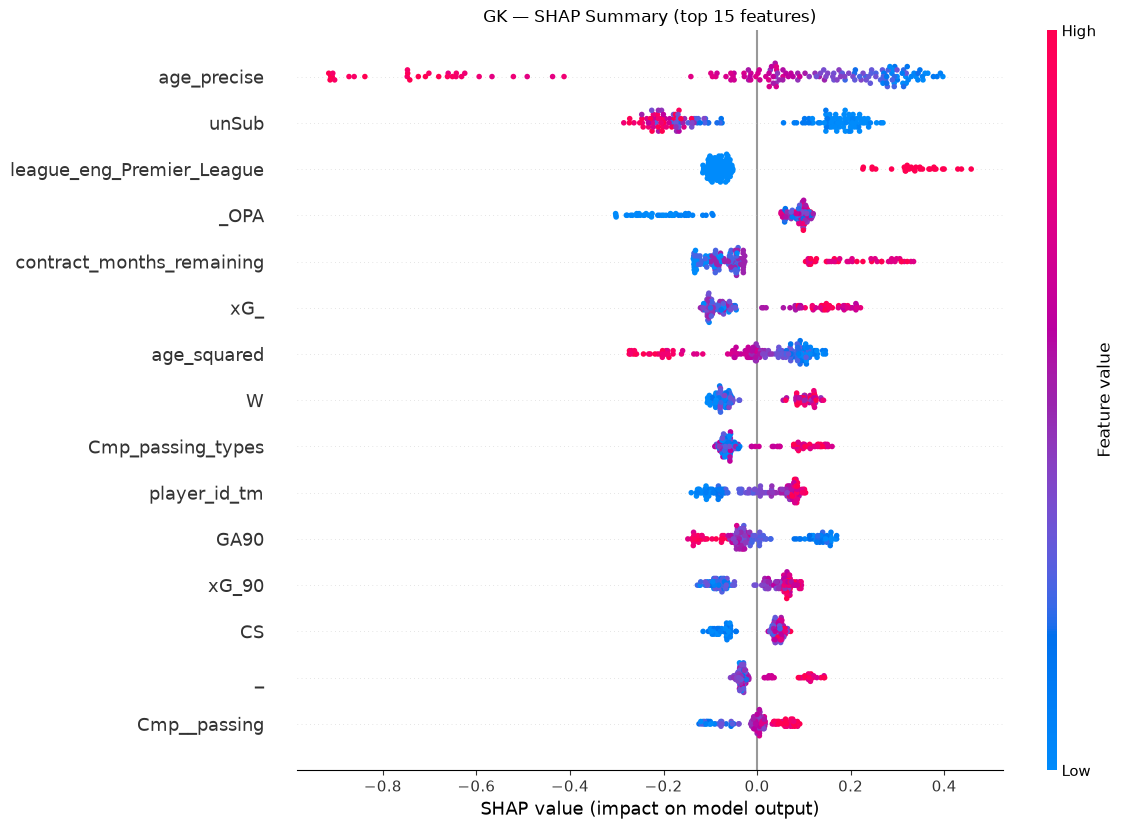

Plot saved to shap_summary_gk.png

All SHAP values computed and saved.


In [12]:
import shap
import matplotlib.pyplot as plt

best_models = {
    'FWD': (best_model_fwd, X_fwd, y_fwd, lookup_fwd),
    'MID': (best_model_mid, X_mid, y_mid, lookup_mid),
    'DEF': (best_model_def, X_def, y_def, lookup_def),
    'GK':  (best_model_gk,  X_gk,  y_gk,  lookup_gk),
}

def get_shap_explainer(model, X):
    """Pick the right SHAP explainer based on model type."""
    model_type = type(model).__name__
    if model_type == 'Ridge':
        return shap.LinearExplainer(model, X)
    else:
        # TreeExplainer covers RandomForest, XGBRegressor, LGBMRegressor
        return shap.TreeExplainer(model)

shap_values_by_position = {}

for position, (model, X, y, lookup) in best_models.items():
    print(f"\n{'='*50}\nSHAP — {position} ({type(model).__name__})\n{'='*50}")

    explainer = get_shap_explainer(model, X)
    shap_values = explainer.shap_values(X)

    shap_values_by_position[position] = shap_values

    joblib.dump(
        {'shap_values': shap_values, 'X_columns': list(X.columns), 'lookup': lookup},
        SHAP_DIR / f"shap_values_{position.lower()}.pkl"
    )

    print(f"SHAP values shape: {shap_values.shape}")
    print(f"Saved to shap_values_{position.lower()}.pkl")

    try:
        shap.summary_plot(shap_values, X, show=False, max_display=15, plot_size=(12, 8.4))
        plt.title(f"{position} — SHAP Summary (top 15 features)")
        plt.tight_layout()
        plt.savefig(PROCESSED / f"shap_summary_{position.lower()}.png", dpi=150)
        plt.show()
        plt.close()
        print(f"Plot saved to shap_summary_{position.lower()}.png")
    except Exception as e:
        print(f"WARNING: plotting failed ({e}) — SHAP values still saved successfully above.")

print("\nAll SHAP values computed and saved.")

## Section 5 (cont.) — League & Nationality Bias Aggregation

Aggregates the per-player SHAP values into the actual bias quantification 
deliverable. For each position, sums the SHAP contributions across all 
`league_*` columns and all `confed_*` columns per player (since a player 
has exactly one league and one confederation active at a time, this 
collapses the one-hot SHAP values into a single "league contribution" 
and "confederation contribution" per player, in log-market-value units). 
These are back-transformed to euros and aggregated two ways per 
league/confederation: **mean** (direction — premium or discount) and 
**mean absolute value** (importance, regardless of direction). Together 
these form `bias_summary_league.csv` and `bias_summary_confederation.csv` 
— the core RQ2 deliverable, and the numeric backbone for the dashboard's 
Bias Explorer page.

All outputs are written directly to `data/processed/dashboard/`, so the 
dashboard folder is populated as a side effect of running this notebook.

In [13]:
def aggregate_bias(position, shap_values, X, model, lookup):
    """Per-player league/confed SHAP contribution in log space (primary,
    reported metric). The *_counterfactual_eur columns are a SHAP-derived
    euro attribution, NOT a true counterfactual: they back-transform the
    difference between the full log-space prediction and that same
    prediction with the league/confed SHAP contribution subtracted out —
    there is no re-prediction with the league/confed features actually
    changed. Because the back-transform (expm1) is nonlinear, this is an
    approximation of the euro-scale effect, not an exact one; the
    log-space SHAP values above remain the primary, exact metric."""

    league_cols = [c for c in X.columns if c.startswith('league_')]
    confed_cols = [c for c in X.columns if c.startswith('confed_')]

    league_shap_idx = [X.columns.get_loc(c) for c in league_cols]
    confed_shap_idx = [X.columns.get_loc(c) for c in confed_cols]

    player_league_shap = shap_values[:, league_shap_idx].sum(axis=1)
    player_confed_shap = shap_values[:, confed_shap_idx].sum(axis=1)

    league_active = X[league_cols].idxmax(axis=1).str.replace('league_', '', regex=False)
    confed_active = X[confed_cols].idxmax(axis=1).str.replace('confed_', '', regex=False)

    # full model prediction (log scale) per player, used to derive the SHAP-based euro attribution below
    full_pred_log = model.predict(X)

    player_df = pd.DataFrame({
        'Player': lookup['Player'].values if 'Player' in lookup.columns else np.arange(len(X)),
        'position': position,
        'league': league_active.values,
        'confederation': confed_active.values,
        'league_shap_log': player_league_shap,   # PRIMARY metric — additive, model-space
        'confed_shap_log': player_confed_shap,   # PRIMARY metric — additive, model-space
    })

    # SHAP-derived euro attribution: actual prediction vs. prediction with the
    # league/confed SHAP contribution subtracted out (both back-transformed).
    # An approximation, not a re-prediction with an intervened feature.
    euro_actual = back_transform(full_pred_log)
    euro_without_league = back_transform(full_pred_log - player_league_shap)
    euro_without_confed = back_transform(full_pred_log - player_confed_shap)

    player_df['league_counterfactual_eur'] = euro_actual - euro_without_league
    player_df['confed_counterfactual_eur'] = euro_actual - euro_without_confed

    return player_df


all_bias_rows = []

for position, (model, X, y, lookup) in best_models.items():
    shap_values = shap_values_by_position[position]
    player_bias_df = aggregate_bias(position, shap_values, X, model, lookup)
    all_bias_rows.append(player_bias_df)

per_player_bias = pd.concat(all_bias_rows, ignore_index=True)

# league-level: mean_shap_log/mean_abs_shap_log are the PRIMARY reported metrics.
# mean_counterfactual_eur is dashboard-only — label it clearly as model-estimated,
# not an observed market premium.
league_summary = per_player_bias.groupby(['position', 'league']).agg(
    n_players=('league_shap_log', 'size'),
    mean_shap_log=('league_shap_log', 'mean'),
    mean_abs_shap_log=('league_shap_log', lambda s: s.abs().mean()),
    mean_counterfactual_eur=('league_counterfactual_eur', 'mean'),
).reset_index()

confed_summary = per_player_bias.groupby(['position', 'confederation']).agg(
    n_players=('confed_shap_log', 'size'),
    mean_shap_log=('confed_shap_log', 'mean'),
    mean_abs_shap_log=('confed_shap_log', lambda s: s.abs().mean()),
    mean_counterfactual_eur=('confed_counterfactual_eur', 'mean'),
).reset_index()

print("=== League Summary (log-space = primary/reported; counterfactual_eur = dashboard-only) ===")
print(league_summary.sort_values(['position', 'mean_shap_log'], ascending=[True, False]))
print("\n=== Confederation Summary ===")
print(confed_summary.sort_values(['position', 'mean_shap_log'], ascending=[True, False]))

DASHBOARD_DIR = PROCESSED / "dashboard"
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

league_summary.to_csv(DASHBOARD_DIR / "bias_summary_league.csv", index=False)
confed_summary.to_csv(DASHBOARD_DIR / "bias_summary_confederation.csv", index=False)
per_player_bias.to_csv(DASHBOARD_DIR / "per_player_bias.csv", index=False)

print(f"\nSaved bias_summary_league.csv, bias_summary_confederation.csv, per_player_bias.csv to {DASHBOARD_DIR}")

=== League Summary (log-space = primary/reported; counterfactual_eur = dashboard-only) ===
   position              league  n_players  mean_shap_log  mean_abs_shap_log  mean_counterfactual_eur
1       DEF  eng_Premier_League        160       0.647641           0.647641             9.287741e+06
2       DEF          es_La_Liga        143      -0.146000           0.146000            -1.120340e+06
4       DEF          it_Serie_A        179      -0.148049           0.148049            -1.109047e+06
0       DEF       de_Bundesliga        150      -0.151409           0.151409            -1.211692e+06
3       DEF          fr_Ligue_1        146      -0.230612           0.230612            -1.831023e+06
6       FWD  eng_Premier_League        106       0.525897           0.525897             9.877254e+06
9       FWD          it_Serie_A        104      -0.098399           0.098399            -9.735097e+05
5       FWD       de_Bundesliga         83      -0.099889           0.100351            -9.39

## Section 6 — Model Diagnostics

Generates cross-validated diagnostics for each position's best model, 
using the same 5-fold stratified CV configuration as Section 3. For each 
position, one figure with three panels (predicted vs actual, residuals 
vs predicted, residual distribution) is produced and saved. Cross-validated 
predictions (not in-sample) are used here specifically to avoid overstating 
model fit, since these figures support the validity of the SHAP-based 
analysis in Section 5.


Diagnostics — FWD


CV metrics: RMSE=0.6550  R2=0.7589  residual mean=-0.0028


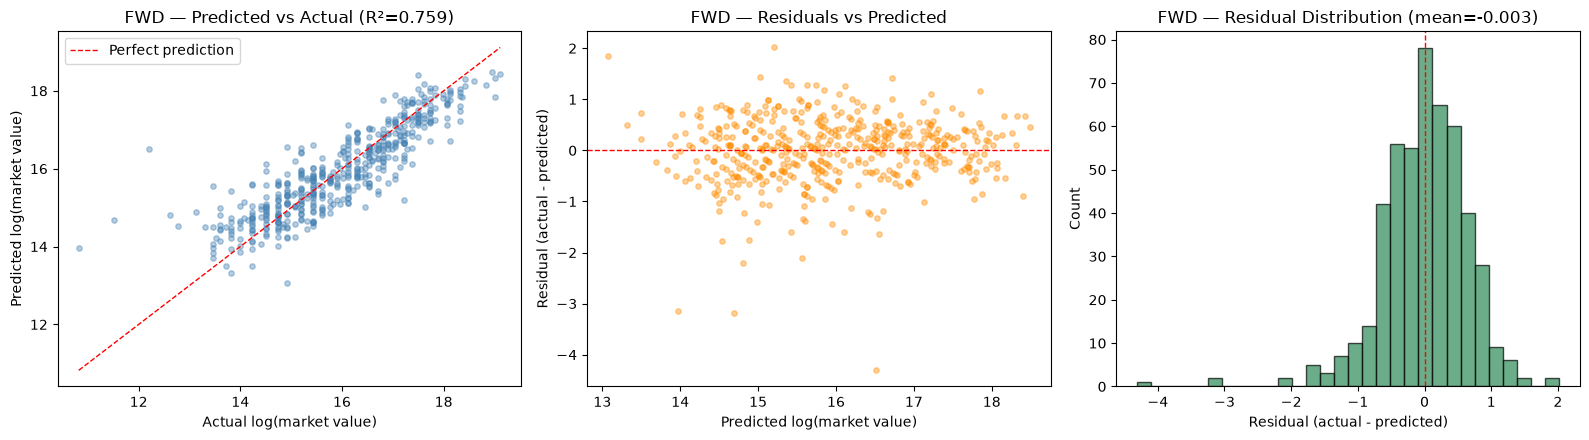

Saved diagnostics_fwd.png


Saved individual panel PNGs for fwd

Diagnostics — MID


CV metrics: RMSE=0.6141  R2=0.7490  residual mean=0.0095


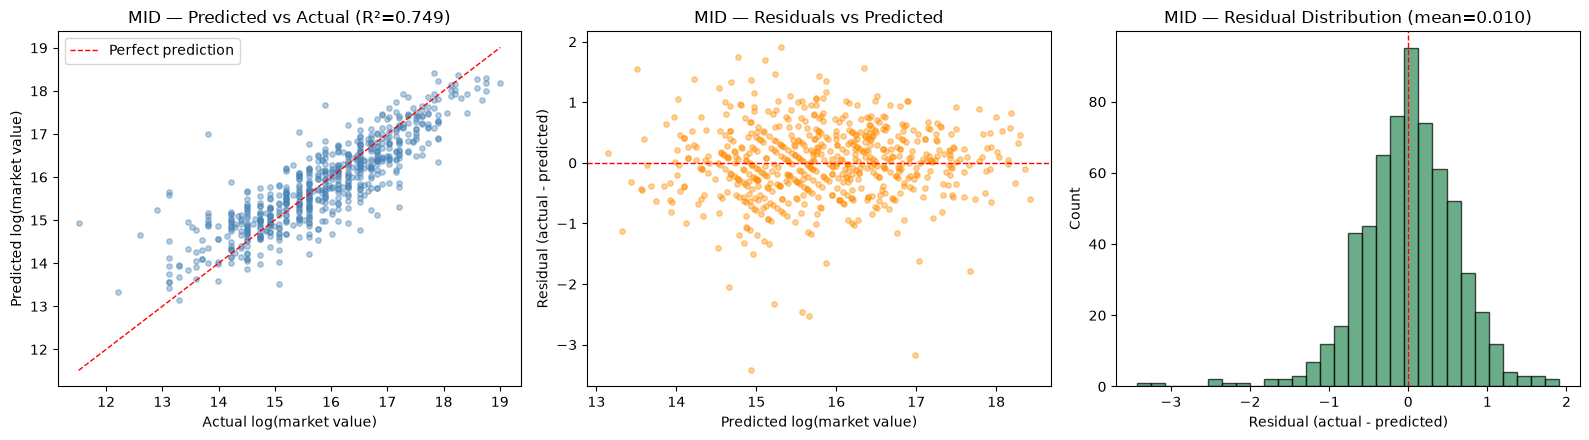

Saved diagnostics_mid.png


Saved individual panel PNGs for mid

Diagnostics — DEF


CV metrics: RMSE=0.5653  R2=0.7843  residual mean=-0.0033


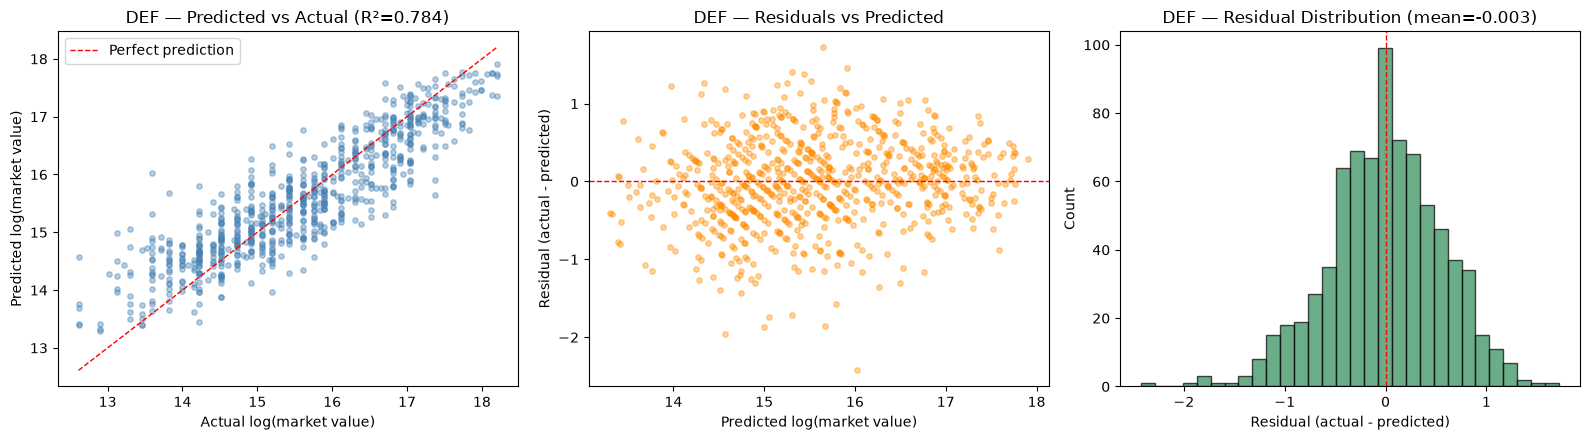

Saved diagnostics_def.png


Saved individual panel PNGs for def

Diagnostics — GK


CV metrics: RMSE=0.7240  R2=0.6875  residual mean=-0.0208


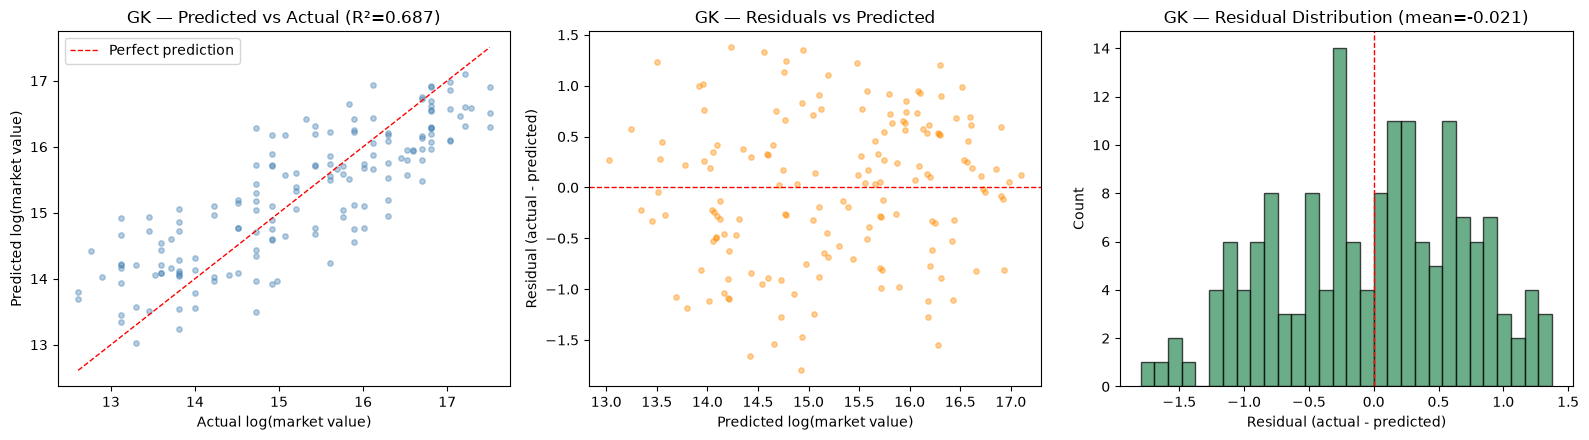

Saved diagnostics_gk.png


Saved individual panel PNGs for gk

Saved diagnostics_summary.csv to ../data/processed_june2025/dashboard
  position  RMSE_log   MAE_log        R2  MAPE_eur_pct
0      FWD  0.655046  0.484112  0.758885     78.188875
1      MID  0.614066  0.458352  0.749011     60.890435
2      DEF  0.565270  0.440369  0.784341     51.351975
3       GK  0.724037  0.602776  0.687485     74.068017


In [14]:
FIGURES_DIR = PROCESSED / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

cv_predictions = {}
diagnostics_summary = []

for position, (model, X, y, lookup) in best_models.items():
    print(f"\n{'='*50}\nDiagnostics — {position}\n{'='*50}")

    bins = make_strat_bins(y, n_bins=5)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_folds = list(skf.split(X, bins))

    y_pred_cv = cross_val_predict(model, X, y, cv=cv_folds)
    cv_predictions[position] = y_pred_cv
    residuals = y - y_pred_cv

    metrics = eval_metrics(y, y_pred_cv)
    diagnostics_summary.append({'position': position, **metrics})
    print(f"CV metrics: RMSE={metrics['RMSE_log']:.4f}  R2={metrics['R2']:.4f}  "
          f"residual mean={residuals.mean():.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].scatter(y, y_pred_cv, alpha=0.4, s=15, color='steelblue')
    lims = [min(y.min(), y_pred_cv.min()), max(y.max(), y_pred_cv.max())]
    axes[0].plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
    axes[0].set_xlabel('Actual log(market value)')
    axes[0].set_ylabel('Predicted log(market value)')
    axes[0].set_title(f'{position} — Predicted vs Actual (R²={metrics["R2"]:.3f})')
    axes[0].legend()

    axes[1].scatter(y_pred_cv, residuals, alpha=0.4, s=15, color='darkorange')
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Predicted log(market value)')
    axes[1].set_ylabel('Residual (actual - predicted)')
    axes[1].set_title(f'{position} — Residuals vs Predicted')

    axes[2].hist(residuals, bins=30, color='seagreen', edgecolor='black', alpha=0.7)
    axes[2].axvline(0, color='red', linestyle='--', linewidth=1)
    axes[2].set_xlabel('Residual (actual - predicted)')
    axes[2].set_ylabel('Count')
    axes[2].set_title(f'{position} — Residual Distribution (mean={residuals.mean():.3f})')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"diagnostics_{position.lower()}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Saved diagnostics_{position.lower()}.png")

    # --- Individual panel exports (for dashboard) ---
    fig1, ax1 = plt.subplots(figsize=(7.2, 2.8))
    ax1.scatter(y, y_pred_cv, alpha=0.4, s=15, color='steelblue')
    ax1.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
    ax1.set_xlabel('Actual log(market value)')
    ax1.set_ylabel('Predicted log(market value)')
    ax1.set_title(f'{position} — Predicted vs Actual (R²={metrics["R2"]:.3f})')
    ax1.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"diagnostics_{position.lower()}_pred_vs_actual.png", dpi=300, bbox_inches='tight')
    plt.close(fig1)

    fig2, ax2 = plt.subplots(figsize=(7.2, 2.8))
    ax2.scatter(y_pred_cv, residuals, alpha=0.4, s=15, color='darkorange')
    ax2.axhline(0, color='red', linestyle='--', linewidth=1)
    ax2.set_xlabel('Predicted log(market value)')
    ax2.set_ylabel('Residual (actual - predicted)')
    ax2.set_title(f'{position} — Residuals vs Predicted')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"diagnostics_{position.lower()}_residuals_vs_predicted.png", dpi=300, bbox_inches='tight')
    plt.close(fig2)

    fig3, ax3 = plt.subplots(figsize=(7.2, 2.8))
    ax3.hist(residuals, bins=30, color='seagreen', edgecolor='black', alpha=0.7)
    ax3.axvline(0, color='red', linestyle='--', linewidth=1)
    ax3.set_xlabel('Residual (actual - predicted)')
    ax3.set_ylabel('Count')
    ax3.set_title(f'{position} — Residual Distribution (mean={residuals.mean():.3f})')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"diagnostics_{position.lower()}_residual_dist.png", dpi=300, bbox_inches='tight')
    plt.close(fig3)

    print(f"Saved individual panel PNGs for {position.lower()}")

diagnostics_df = pd.DataFrame(diagnostics_summary)
diagnostics_df.to_csv(DASHBOARD_DIR / "diagnostics_summary.csv", index=False)
print(f"\nSaved diagnostics_summary.csv to {DASHBOARD_DIR}")
print(diagnostics_df)


## Section 7 — Undervalued Player Identification

Two different prediction sources are used here for two different
purposes, and both are saved so neither is lost for later analysis:

- **Display columns** (`predicted_value_eur`, `value_gap_eur`,
  `value_ratio`) use the **final trained model's own prediction** —
  `model.predict(X)` on the model already fit on 100% of the data, the
  same fitted model SHAP explains in Section 5. This keeps every
  user-facing "Model Estimated Value" (Value Finder, Player Explorer)
  numerically reconcilable with its own SHAP waterfall: base_value +
  sum(shap_values) = model.predict(X) is an exact TreeSHAP identity,
  and only holds if the displayed prediction actually IS model.predict(X).
  A prediction from `cross_val_predict` isn't the output of any single
  fitted model (each row potentially comes from a different fold's
  model), so it has no SHAP decomposition that could ever reconcile with
  it — this is a correctness requirement for SHAP consistency, not a
  stylistic choice. It does mean these display columns carry the same
  in-sample optimism that motivated Section 6's diagnostics being
  computed out-of-fold in the first place (see Model Performance for
  the honest, cross-validated accuracy of the underlying model) —
  "Model Estimated Value" can run optimistic for players who are
  statistical outliers within their position, most visibly at the very
  top of the value distribution.
- **`undervalued_flag`** is computed from `oof_predicted_value_eur` /
  `oof_value_ratio` — the **out-of-fold** predictions from
  `cv_predictions[position]` (Section 6), where a player's own valuation
  is never used to help predict itself. This keeps the flag itself free
  of the in-sample optimism above: `undervalued_flag` marks the top 10%
  of `oof_value_ratio` within each position, so "undervalued" reflects
  genuine held-out generalisation, not overfitting.

Both prediction sources — final-model and out-of-fold — are saved as
separate, permanent columns in `df_predictions.csv` (`predicted_value_eur`/
`value_ratio` vs. `oof_predicted_value_eur`/`oof_value_ratio`), so
neither is discarded and both remain available for dissertation analysis.

In [15]:
all_predictions = []

for position, (model, X, y, lookup) in best_models.items():
    print(f"\n{'='*50}\nUndervalued Players — {position}\n{'='*50}")

    # final trained model's own prediction (same fitted model SHAP
    # explains in Section 5) — used for every user-facing display value
    y_pred_final_log = model.predict(X)

    # out-of-fold prediction from Section 6's cross_val_predict — used
    # ONLY for the undervalued_flag threshold, never displayed directly
    y_pred_oof_log = cv_predictions[position]

    pred_df = pd.DataFrame({
        'Player': lookup['Player'].values if 'Player' in lookup.columns else np.arange(len(X)),
        'position': position,
        'actual_value_eur': back_transform(y.values),
        'predicted_value_eur': back_transform(y_pred_final_log),
        'oof_predicted_value_eur': back_transform(y_pred_oof_log),
    })

    pred_df['value_gap_eur'] = pred_df['predicted_value_eur'] - pred_df['actual_value_eur']
    pred_df['value_ratio'] = pred_df['predicted_value_eur'] / pred_df['actual_value_eur']
    pred_df['oof_value_ratio'] = pred_df['oof_predicted_value_eur'] / pred_df['actual_value_eur']

    # undervalued_flag threshold uses the OOF ratio, not the displayed
    # (final-model) ratio — see Section 7 markdown above
    threshold = pred_df['oof_value_ratio'].quantile(0.90)
    pred_df['undervalued_flag'] = pred_df['oof_value_ratio'] >= threshold

    print(f"Top 10% OOF value_ratio threshold: {threshold:.3f}  "
          f"({pred_df['undervalued_flag'].sum()} players flagged)")

    all_predictions.append(pred_df)

df_predictions = pd.concat(all_predictions, ignore_index=True)

print(f"\nTotal players: {len(df_predictions)}")
print(f"Total flagged undervalued: {df_predictions['undervalued_flag'].sum()}")

print("\n=== Top 10 most undervalued players (all positions, by OOF ratio) ===")
top10 = df_predictions.sort_values('oof_value_ratio', ascending=False).head(10)
print(top10[['Player', 'position', 'actual_value_eur', 'predicted_value_eur', 'oof_predicted_value_eur', 'oof_value_ratio', 'value_gap_eur']])


Undervalued Players — FWD
Top 10% OOF value_ratio threshold: 1.982  (49 players flagged)

Undervalued Players — MID
Top 10% OOF value_ratio threshold: 1.938  (64 players flagged)

Undervalued Players — DEF
Top 10% OOF value_ratio threshold: 2.023  (78 players flagged)

Undervalued Players — GK
Top 10% OOF value_ratio threshold: 2.831  (16 players flagged)

Total players: 2061
Total flagged undervalued: 207

=== Top 10 most undervalued players (all positions, by OOF ratio) ===
                Player position  actual_value_eur  predicted_value_eur  oof_predicted_value_eur  oof_value_ratio  value_gap_eur
393              Sávio      FWD          200000.0         3.918113e+05             1.483886e+07        74.194310   1.918113e+05
748     Liam Henderson      MID          100000.0         2.552319e+05             3.068138e+06        30.681377   1.552319e+05
963        Nicolás Paz      MID         1000000.0         1.901263e+06             2.391375e+07        23.913748   9.012628e+05
368   

## Section 8 — Final Save & Verification

Saves `df_predictions.csv` to both `data/processed/` and 
`data/processed/dashboard/`, then verifies that every expected NB3 
output — trained models, SHAP values, all CSVs, and all figures — 
actually exists on disk, printing filename and size for each. This is 
the closing checkpoint for NB3: if everything below reports PASS, the 
modelling pipeline is complete and the dashboard build can proceed 
entirely from these saved artifacts without touching NB3 again.

In [16]:
df_predictions.to_csv(PROCESSED / "df_predictions.csv", index=False)
df_predictions.to_csv(DASHBOARD_DIR / "df_predictions.csv", index=False)
print(f"Saved df_predictions.csv to {PROCESSED} and {DASHBOARD_DIR}")

# --- Verification ---
positions = ['fwd', 'mid', 'def', 'gk']

expected_files = []

for pos in positions:
    expected_files.append(MODELS_DIR / f"best_model_{pos}.pkl")
expected_files.append(MODELS_DIR / "best_model_ablation.pkl")

for pos in positions:
    expected_files.append(SHAP_DIR / f"shap_values_{pos}.pkl")

expected_files += [
    PROCESSED / "results_summary.csv",
    PROCESSED / "ablation_results.csv",
    DASHBOARD_DIR / "bias_summary_league.csv",
    DASHBOARD_DIR / "bias_summary_confederation.csv",
    DASHBOARD_DIR / "per_player_bias.csv",
    PROCESSED / "df_predictions.csv",
    DASHBOARD_DIR / "df_predictions.csv",
]

# figures: SHAP summaries (Section 5) + diagnostics (Section 6)
for pos in positions:
    expected_files.append(PROCESSED / f"shap_summary_{pos}.png")
for pos in positions:
    expected_files.append(FIGURES_DIR / f"diagnostics_{pos}.png")

print(f"\n{'='*60}\nVERIFYING {len(expected_files)} EXPECTED OUTPUTS\n{'='*60}")

all_present = True
for f in expected_files:
    if f.exists():
        size_kb = f.stat().st_size / 1024
        print(f"  OK   {f.name:40s} ({size_kb:,.1f} KB)")
    else:
        print(f"  MISSING   {f}")
        all_present = False

print(f"\n{'='*60}")
if all_present:
    print("PASS: All expected NB3 outputs generated successfully.")
else:
    print("FAIL: Missing outputs detected.")
print(f"{'='*60}")

Saved df_predictions.csv to ../data/processed_june2025 and ../data/processed_june2025/dashboard

VERIFYING 24 EXPECTED OUTPUTS
  OK   best_model_fwd.pkl                       (239.4 KB)
  OK   best_model_mid.pkl                       (729.2 KB)
  OK   best_model_def.pkl                       (355.6 KB)
  OK   best_model_gk.pkl                        (343.9 KB)
  OK   best_model_ablation.pkl                  (351.8 KB)
  OK   shap_values_fwd.pkl                      (330.6 KB)
  OK   shap_values_mid.pkl                      (814.7 KB)
  OK   shap_values_def.pkl                      (526.5 KB)
  OK   shap_values_gk.pkl                       (245.8 KB)
  OK   results_summary.csv                      (2.7 KB)
  OK   ablation_results.csv                     (0.8 KB)
  OK   bias_summary_league.csv                  (1.6 KB)
  OK   bias_summary_confederation.csv           (1.1 KB)
  OK   per_player_bias.csv                      (196.1 KB)
  OK   df_predictions.csv                       (253.7 

## Section 9 — Comparable Players (Nearest Neighbours)

A separate, additive artifact for player comps: for each position, finds
each player's 5 most statistically similar teammates-in-position, using
only pre-model football signal — not league, nationality/confederation,
market value, contract status, career-stage, or any SHAP-derived output.

**Feature set.** Starts from each position's own `X_{pos}` (Section 3) —
the exact feature matrix each best model was trained on — and narrows it
further to football-performance, age, and playing-time columns only.
Explicitly excluded: `league_*`/`confed_*` one-hot dummies (both are raw
model inputs, not performance), `contract_months_remaining` /
`missing_contract`, `career_stage_*` dummies, and `height_in_cm` /
`foot_*` / `player_id_tm` (physical/identifier attributes rather than
performance, age, or playing-time signal). SHAP outputs were never part
of `X_{pos}` in the first place, so there's nothing to strip there.

**Similarity metric: Euclidean distance on z-scored features, not cosine
similarity.** Every retained column is standardized first (`StandardScaler`,
zero mean / unit variance), which already puts a 90-minute stat and a
per-cent stat on the same footing. Once features are on a common scale,
Euclidean distance measures the thing we actually want — how far apart two
players' *magnitudes* are across every standardized stat — which is the
standard basis for statistical "player comp" tools. Cosine similarity
instead measures the angle between two profile vectors and is scale-
invariant, so it would treat a player with uniformly low z-scores across
the board as "similar" to one with uniformly high z-scores in the same
stats (same direction, different magnitude) — exactly the distinction
z-scoring was meant to preserve. Euclidean is the better fit here.

**Output.** `comparable_players.csv` — one row per player, columns
`player_id, neighbor_1_id ... neighbor_5_id`. `player_id` is `"{Player} —
{Squad}"` (verified unique within each position — the handful of players
who transferred mid-season appear once per club, and Player+Squad
disambiguates them, consistent with how the dashboard already handles the
same duplicates elsewhere).

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

N_NEIGHBORS = 5

# Prefixes/exact names to strip from each position's own X (Section 3's
# already-built model feature matrix) before computing comparability —
# see the markdown above for why each group is excluded.
COMPARABLE_EXCLUDE_PREFIXES = ('league_', 'confed_', 'career_stage_', 'foot_')
COMPARABLE_EXCLUDE_EXACT = {
    'contract_months_remaining', 'missing_contract', 'height_in_cm', 'player_id_tm',
}

def comparable_feature_columns(X):
    return [
        c for c in X.columns
        if c not in COMPARABLE_EXCLUDE_EXACT and not c.startswith(COMPARABLE_EXCLUDE_PREFIXES)
    ]


def compute_comparable_players(position, X, lookup, n_neighbors=N_NEIGHBORS):
    """Z-score the position's performance/age/playing-time features, then
    find each player's n_neighbors nearest teammates-in-position by
    Euclidean distance. Returns (artifact_df, neighbor_distances) — the
    distances are kept only for the verification step below, not saved."""
    keep_cols = comparable_feature_columns(X)
    X_comp = X[keep_cols]

    X_scaled = StandardScaler().fit_transform(X_comp)

    player_ids = (lookup['Player'] + ' — ' + lookup['Squad']).values
    assert not pd.Series(player_ids).duplicated().any(), f"{position}: player_id collision"

    # n_neighbors+1 because a player's own nearest neighbour is always
    # itself (distance 0) — dropped via [:, 1:] below.
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1, metric='euclidean')
    nn.fit(X_scaled)
    distances, indices = nn.kneighbors(X_scaled)
    neighbor_idx = indices[:, 1:n_neighbors + 1]
    neighbor_dist = distances[:, 1:n_neighbors + 1]

    artifact = pd.DataFrame({'player_id': player_ids})
    for k in range(n_neighbors):
        artifact[f'neighbor_{k + 1}_id'] = player_ids[neighbor_idx[:, k]]

    print(f"{position}: {len(keep_cols)} comparability features, {len(player_ids)} players")
    return artifact, neighbor_dist


comparable_by_position = {}
neighbor_distances_by_position = {}

for position, X, lookup in [
    ('FWD', X_fwd, lookup_fwd),
    ('MID', X_mid, lookup_mid),
    ('DEF', X_def, lookup_def),
    ('GK',  X_gk,  lookup_gk),
]:
    artifact, neighbor_dist = compute_comparable_players(position, X, lookup)
    comparable_by_position[position] = artifact
    neighbor_distances_by_position[position] = neighbor_dist

comparable_players = pd.concat(comparable_by_position.values(), ignore_index=True)

comparable_players.to_csv(DASHBOARD_DIR / "comparable_players.csv", index=False)
print(f"\nSaved comparable_players.csv ({len(comparable_players)} rows) to {DASHBOARD_DIR}")
comparable_players.head()

FWD: 132 comparability features, 487 players
MID: 132 comparability features, 637 players
DEF: 132 comparability features, 778 players
GK: 164 comparability features, 159 players



Saved comparable_players.csv (2061 rows) to ../data/processed_june2025/dashboard


,player_id,neighbor_1_id,neighbor_2_id,neighbor_3_id,neighbor_4_id,neighbor_5_id
0,Matthis Abline — Nantes,Adam Hložek — Hoffenheim,Andrea Pinamonti — Genoa,Fábio Silva — Las Palmas,Jean-Philippe Mateta — Crystal Palace,Dany Mota — Monza
1,Tammy Abraham — Milan,Eldor Shomurodov — Roma,Thijs Dallinga — Bologna,Williot Swedberg — Celta Vigo,Diogo Jota — Liverpool,Christopher Nkunku — Chelsea
2,Akor Adams — Montpellier,Benedikt Pichler — Holstein Kiel,Keinan Davis — Udinese,Christian Kouamé — Empoli,Emmanuel Sabbi — Le Havre,Andy Delort — Montpellier
3,Che Adams — Torino,Artem Dovbyk — Roma,Andrea Pinamonti — Genoa,Jean-Philippe Mateta — Crystal Palace,Patrick Cutrone — Como,Fábio Silva — Las Palmas
4,Junior Adamu — Freiburg,Frank Magri — Toulouse,Dominic Calvert-Lewin — Everton,M'Bala Nzola — Lens,Rasmus Højlund — Manchester Utd,Cyle Larin — Mallorca


### Verification

Two checks: (1) distance summary stats per position, to confirm neighbours
sit meaningfully closer than a random pair of players would; (2) a manual
spot-check of a few players' top-5 neighbours against their raw stats.

In [19]:
# --- Check 1: neighbour distances by position -----------------------------
# A useful reference point: the *average pairwise* distance between two
# random players in the same standardized space (computed directly, not
# estimated) — if neighbour distances are much smaller than this, the
# nearest-neighbour search is doing real work, not returning near-random
# matches.
from scipy.spatial.distance import pdist

print(f"{'Position':<10}{'Players':>8}{'Neighbor mean':>16}{'Neighbor min':>14}"
      f"{'Neighbor max':>14}{'Random-pair mean':>19}")
for position, X, lookup in [
    ('FWD', X_fwd, lookup_fwd), ('MID', X_mid, lookup_mid),
    ('DEF', X_def, lookup_def), ('GK', X_gk, lookup_gk),
]:
    keep_cols = comparable_feature_columns(X)
    X_scaled = StandardScaler().fit_transform(X[keep_cols])
    random_pair_mean = pdist(X_scaled, metric='euclidean').mean()
    d = neighbor_distances_by_position[position]
    print(f"{position:<10}{len(X):>8}{d.mean():>16.2f}{d.min():>14.2f}"
          f"{d.max():>14.2f}{random_pair_mean:>19.2f}")

Position   Players   Neighbor mean  Neighbor min  Neighbor max   Random-pair mean
FWD            487            8.32          4.34         25.80              15.29
MID            637            8.36          4.52         19.97              15.40
DEF            778            8.19          4.23         26.85              15.44
GK             159            9.98          4.83         21.32              16.45


In [20]:
# --- Check 2: manual spot-check of a few players' neighbours --------------
SPOT_CHECK_STATS = {
    'FWD': ['Gls', 'Ast', 'xG', 'Sh_shooting', 'SoT'],
    'MID': ['Ast', 'KP', 'PrgP', 'Tkl', 'Int'],
    'DEF': ['Tkl', 'Int', 'Clr', 'Won', 'Won%'],
    'GK':  ['Saves', 'Save%', 'CS', 'GA90'],
}
SPOT_CHECK_PLAYERS = [
    ('FWD', 'Kylian Mbapp\u00e9'),
    ('DEF', 'Virgil van Dijk'),
    ('GK', 'Aaron Ramsdale'),
]

for position, player_name in SPOT_CHECK_PLAYERS:
    df_pos = dfs[position]
    artifact = comparable_by_position[position]
    matches = artifact[artifact['player_id'].str.startswith(player_name)]
    row = matches.iloc[0]
    neighbor_ids = [row[f'neighbor_{k}_id'] for k in range(1, 6)]
    neighbor_names = [n.split(' \u2014 ')[0] for n in neighbor_ids]

    print(f"\n{'='*70}\n{position} — {row['player_id']} — top-5 nearest neighbours\n{'='*70}")
    stat_cols = ['Player', 'Squad'] + SPOT_CHECK_STATS[position]
    subset = df_pos[df_pos['Player'].isin([player_name] + neighbor_names)][stat_cols]
    print(subset.to_string(index=False))


FWD — Kylian Mbappé — Real Madrid — top-5 nearest neighbours


         Player         Squad  Gls  Ast   xG  Sh_shooting  SoT
Ousmane Dembélé     Paris S-G   21    6 16.6           96   49
Mason Greenwood     Marseille   21    5 16.3          111   45
 Alexander Isak Newcastle Utd   23    6 20.3           95   41
Vinicius Júnior   Real Madrid   11    8 10.4           78   24
  Kylian Mbappé   Real Madrid   31    3 25.9          152   75
  Mohamed Salah     Liverpool   29   18 25.2          121   50

DEF — Virgil van Dijk — Liverpool — top-5 nearest neighbours
            Player         Squad  Tkl  Int  Clr  Won  Won%
      Levi Colwill       Chelsea   47   33  118   82  60.7
Jan Paul van Hecke      Brighton   45   24  142   82  62.1
       Kim Min-jae Bayern Munich   35   37   91   82  65.6
     Amir Rrahmani        Napoli   39   27  179  124  69.3
      Jonathan Tah    Leverkusen   19   36  157   77  77.0
   Virgil van Dijk     Liverpool   38   56  190  119  72.1

GK — Aaron Ramsdale — Southampton — top-5 nearest neighbours
          Player      